This is part 1 of a tutorial series. We recommend following them in order, starting with [Part 0: Welcome to `musica`](0.%20Welcome%20to%20MUSICA.ipynb).

# Chapman Cycle Box Model

This tutorial implements a box model of the [Chapman cycle](https://en.wikipedia.org/wiki/Chapman_cycle) — a set of reactions describing stratospheric ozone chemistry.

In previous tutorials, we used `micm` and `tuv-x` independently. Now, we're going to use them together to calculate photolysis rate constants and solve the Chapman mechanism for a real geographic location (Boulder, CO) over 12 hours beginning at 6:30 AM local time. The chemistry will be solved for 10 vertically stacked grid cells in the stratosphere (20–30 km), where ozone chemistry is most active.

## 1. Imports

In [1]:
import json
from datetime import datetime, time, timedelta
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import pvlib
import ussa1976
import xarray as xr

import musica
from musica.constants import GAS_CONSTANT
from musica.mechanism_configuration import Parser
from musica.micm.solver_result import SolverState
from musica.tuvx import vTS1
from musica.utils import find_config_path

SECONDS_PER_HOUR = 3600

## 2. Location and Simulation Time

We simulate over Boulder, CO. The simulation starts at 6:30 Mountain Time so we capture the morning rise in photolysis rates as the sun climbs.

All times are tracked as timezone-aware `datetime` objects. We use UTC internally and convert to local time for display.

In [2]:
boulder = (40.01879858223568, -105.27492413846649)  # (latitude, longitude)
boulder_tz = ZoneInfo("America/Denver")

today_local = datetime.now(boulder_tz).date()
sim_local  = datetime.combine(today_local, time(6, 30), tzinfo=boulder_tz)
sim_time    = sim_local.astimezone(ZoneInfo("UTC"))

print(f"Simulation start (UTC):   {sim_time}")
print(f"Simulation start (local): {sim_time.astimezone(boulder_tz)}")

Simulation start (UTC):   2026-04-03 12:30:00+00:00
Simulation start (local): 2026-04-03 06:30:00-06:00


## 3. Load `tuv-x` and Define a Helper to Compute Photolysis Rates

We load the vTS1 `tuv-x` calculator once and keep it alive for the duration of the simulation. The photolysis reactions in the Chapman mechanism are available from this `tuv-x` configuration.

In [3]:
tuvx = vTS1.get_tuvx_calculator()

tuv_path = find_config_path("tuvx", "ts1_tsmlt.json")
with open(tuv_path, 'r') as f:
    data = json.load(f)
alias_mappings = data.get('__CAM options', {}).get('aliasing', {}).get('pairs', {})

print(f"Loaded {len(alias_mappings)} photolysis rate alias mappings")

Loaded 122 photolysis rate alias mappings


Next, let's create a convenience function we can call at each time step to get the photolysis rate constants, by:
1. Using `pvlib` to compute the solar zenith angle (SZA) at Boulder for that moment.
2. Running TUV-x with that SZA to get photolysis rate constants at every altitude.
3. Mapping the TUV-x reaction labels to the `PHOTO.*` parameter names expected by the MICM Chapman mechanism using the alias table in the config file.

In [4]:
def get_tuv_rates(utc_time, num_grid_cells, start=1):
    """Return photolysis rate constants for `num_grid_cells` altitude cells starting at index `start`."""
    lat, lon = boulder
    solpos = pvlib.solarposition.get_solarposition(time=utc_time, latitude=lat, longitude=lon)
    sza_deg = solpos['zenith'].item()

    tuv_rates = tuvx.run(sza=np.deg2rad(sza_deg), earth_sun_distance=1.0)
    end = start + num_grid_cells

    photolysis_rate_constants = {}
    for mapping in alias_mappings:
        label    = mapping['to']
        scale    = mapping.get("scale by", 1)
        tuv_label = mapping['from']
        rate = tuv_rates.sel(reaction=tuv_label).photolysis_rate_constants.values * scale
        photolysis_rate_constants[f'PHOTO.{label}'] = rate[start:end]

    return photolysis_rate_constants, tuv_rates

## 4. Altitude Grid and Atmospheric Conditions

The Chapman cycle is most relevant in the stratosphere (~20–50 km). We use TUV-x altitude grid cells 20–30 (i.e., the 20th through 29th edges), which correspond to approximately 20–30 km. Temperature and pressure at those altitudes come from the US Standard Atmosphere 1976 model.

In [5]:
start          = 20   # TUV-x altitude grid index (skip surface + lower troposphere)
num_grid_cells = 10   # number of stratospheric grid cells

# Compute initial photolysis rates and grab the altitude edges for our grid cells
photolysis_rate_constants, tuv_rates = get_tuv_rates(sim_time, num_grid_cells, start)
vertical_edges = tuv_rates.vertical_edge[start:start + num_grid_cells].data

print(f"Altitude range: {vertical_edges.min():.1f} – {vertical_edges.max():.1f} km")

# US Standard Atmosphere T and P at those altitudes (km -> m)
atm         = ussa1976.compute(z=vertical_edges * 1000, variables=["t", "p"])
temperature = atm['t'].values
pressure    = atm['p'].values

print(f"Temperature range: {temperature.min():.1f} – {temperature.max():.1f} K")
print(f"Pressure range:    {pressure.min():.1f} – {pressure.max():.1f} Pa")

Altitude range: 20.0 – 29.0 km
Temperature range: 216.6 – 225.5 K
Pressure range:    1390.4 – 5529.3 Pa


## 5. Load the Chapman Mechanism and Create the Solver

In [6]:
parser    = Parser()
mechanism = parser.parse(find_config_path("v1", "chapman", "config.json"))

solver = musica.MICM(
    mechanism=mechanism,
    solver_type=musica.SolverType.rosenbrock_standard_order
)
state = solver.create_state(num_grid_cells)

print(f"Chapman mechanism species: {list(state.get_species_ordering().keys())}")
print(f"User-defined rate parameters: {list(state.get_user_defined_rate_parameters().keys())}")
for reaction in mechanism.reactions:
    print(f"[{reaction.type.name}] {reaction.to_equation()}")

Chapman mechanism species: ['N2', 'O1D', 'O3', 'O2', 'O']
User-defined rate parameters: ['PHOTO.jo2_b', 'PHOTO.jo3_b', 'PHOTO.jo3_a']
[Arrhenius] O1D + N2 -> O + N2
[Arrhenius] O1D + O2 -> O + O2
[Arrhenius] O + O3 -> 2O2
[Arrhenius] O + O2 + M -> O3 + M
[Photolysis] O2 -> 2O
[Photolysis] O3 -> O1D + O2
[Photolysis] O3 -> O + O2


## 6. Set Initial Concentrations

Species concentrations are specified as volume mixing ratios and converted to mol m⁻³ using the ideal gas law:

$$[X] = \frac{\chi_X \cdot P}{R T}$$

where $\chi_X$ is the mixing ratio, $P$ pressure (Pa), $R$ the universal gas constant, and $T$ temperature (K). N₂ and O₂ use standard tropospheric mixing ratios; O₃ is initialised at 40 ppb (a typical stratospheric value); O and O(¹D) start at zero.

In [7]:
def mixing_ratio_to_mol_m3(mixing_ratio, pressure, temperature):
    """Convert volume mixing ratio to concentration in mol m-3."""
    return (mixing_ratio * pressure) / (GAS_CONSTANT * temperature)


initial_concentrations = {
    "N2":  mixing_ratio_to_mol_m3(0.78084, pressure, temperature),
    "O2":  mixing_ratio_to_mol_m3(0.20946, pressure, temperature),
    "O":   [0.0] * num_grid_cells,
    "O1D": [0.0] * num_grid_cells,
    "O3":  mixing_ratio_to_mol_m3(40e-9,   pressure, temperature),  # 40 ppb
}

state.set_conditions(temperature, pressure)
state.set_concentrations(initial_concentrations)

# Set photolysis rates
user_defined_dict = state.get_user_defined_rate_parameters()
for key in user_defined_dict:
    user_defined_dict[key] = photolysis_rate_constants[key]
state.set_user_defined_rate_parameters(user_defined_dict)

print("Initial O3 concentrations (mol m-3):")
for alt, conc in zip(vertical_edges, initial_concentrations['O3']):
    print(f"  {alt:.1f} km: {conc:.3e}")

Initial O3 concentrations (mol m-3):
  20.0 km: 1.228e-07
  21.0 km: 1.046e-07
  22.0 km: 8.909e-08
  23.0 km: 7.596e-08
  24.0 km: 6.482e-08
  25.0 km: 5.535e-08
  26.0 km: 4.731e-08
  27.0 km: 4.046e-08
  28.0 km: 3.463e-08
  29.0 km: 2.966e-08


## 7. Run the Simulation

We integrate forward for 12 hours in 15-minute steps. At the end of each step we:
- Advance the simulation clock by the step duration.
- Recompute the solar zenith angle for the new time using `pvlib`.
- Update the photolysis rates on the state before the next step.

This means the photolysis rates change with the diurnal cycle throughout the simulation.

In [8]:
sim_times         = [sim_time]
concentrations    = [state.get_concentrations()]
photo_rate_history = [{k: v.copy() for k, v in state.get_user_defined_rate_parameters().items()}]

time_step         = 15 * 60                    # 15 minutes in seconds
simulation_length = 12 * SECONDS_PER_HOUR      # 12 hours in seconds
current_time      = 0
last_printed_percent = -5

while current_time < simulation_length:
    # Inner loop: accumulate solver sub-steps until a full time_step is consumed
    elapsed = 0
    while elapsed < time_step:
        remaining = time_step - elapsed
        result    = solver.solve(state, remaining)
        elapsed      += result.stats.final_time
        current_time += result.stats.final_time
        if result.state != SolverState.Converged:
            print(f"  Solver state: {result.state} at t={current_time:.0f} s")

    # Advance the wall-clock time and update photolysis rates for the new position
    sim_time += timedelta(seconds=time_step)
    photolysis_rate_constants, _ = get_tuv_rates(sim_time, num_grid_cells, start)

    user_defined_dict = state.get_user_defined_rate_parameters()
    for key in user_defined_dict:
        user_defined_dict[key] = photolysis_rate_constants[key]
    state.set_user_defined_rate_parameters(user_defined_dict)

    sim_times.append(sim_time)
    concentrations.append(state.get_concentrations())
    photo_rate_history.append({k: v.copy() for k, v in state.get_user_defined_rate_parameters().items()})

    current_percent = (current_time / simulation_length) * 100
    rounded = int(current_percent // 5) * 5
    if rounded > last_printed_percent:
        last_printed_percent = rounded
        local_str = sim_time.astimezone(boulder_tz).strftime('%H:%M %Z')
        print(f"Progress: {last_printed_percent}%  (sim time: {local_str})")

print("Simulation complete.")

Progress: 0%  (sim time: 06:45 MDT)
Progress: 5%  (sim time: 07:15 MDT)
Progress: 10%  (sim time: 07:45 MDT)
Progress: 15%  (sim time: 08:30 MDT)
Progress: 20%  (sim time: 09:00 MDT)
Progress: 25%  (sim time: 09:30 MDT)
Progress: 30%  (sim time: 10:15 MDT)
Progress: 35%  (sim time: 10:45 MDT)
Progress: 40%  (sim time: 11:30 MDT)
Progress: 45%  (sim time: 12:00 MDT)
Progress: 50%  (sim time: 12:30 MDT)
Progress: 55%  (sim time: 13:15 MDT)
Progress: 60%  (sim time: 13:45 MDT)
Progress: 65%  (sim time: 14:30 MDT)
Progress: 70%  (sim time: 15:00 MDT)
Progress: 75%  (sim time: 15:30 MDT)
Progress: 80%  (sim time: 16:15 MDT)
Progress: 85%  (sim time: 16:45 MDT)
Progress: 90%  (sim time: 17:30 MDT)
Progress: 95%  (sim time: 18:00 MDT)
Progress: 100%  (sim time: 18:30 MDT)
Simulation complete.


## 8. Build the xarray Dataset

We assemble results into an `xr.Dataset`. Unlike the TS1 tutorial, time is stored as actual `datetime64` timestamps (not elapsed seconds) and photolysis rates are recorded at every time step so we can see how they vary with the diurnal cycle.

In [9]:
final_conditions = state.get_conditions()

data_vars = {
    "temperature": (["height"], final_conditions["temperature"], {"units": "K"}),
    "pressure":    (["height"], final_conditions["pressure"],    {"units": "Pa"}),
    "air_density": (["height"], final_conditions["air_density"], {"units": "mol m-3"}),
}

# Photolysis rates over time
photo_names  = list(photo_rate_history[0].keys())
photo_values = [[params[name] for name in photo_names] for params in photo_rate_history]
data_vars["photolysis_rates"] = (
    ["time", "photolysis_rate_names", "height"],
    photo_values,
    {"units": "s-1"}
)

# Species concentrations
for species in concentrations[0]:
    data_vars[species] = (
        ["time", "height"],
        np.array([c[species] for c in concentrations], dtype=np.float64),
        {"units": "mol m-3"}
    )

ds = xr.Dataset(
    data_vars,
    coords={
        "time":                  np.array(sim_times, dtype="datetime64[s]"),
        "height":                vertical_edges,
        "photolysis_rate_names": np.array(photo_names, dtype="S"),
    }
)

print(ds)

<xarray.Dataset> Size: 32kB
Dimensions:                (height: 10, time: 49, photolysis_rate_names: 3)
Coordinates:
  * height                 (height) float64 80B 20.0 21.0 22.0 ... 28.0 29.0
  * time                   (time) datetime64[s] 392B 2026-04-03T12:30:00 ... ...
  * photolysis_rate_names  (photolysis_rate_names) |S11 33B b'PHOTO.jo2_b' .....
Data variables:
    temperature            (height) float64 80B 216.6 217.6 ... 224.5 225.5
    pressure               (height) float64 80B 5.529e+03 4.729e+03 ... 1.39e+03
    air_density            (height) float64 80B 3.07 2.614 ... 0.8657 0.7415
    photolysis_rates       (time, photolysis_rate_names, height) float64 12kB ...
    N2                     (time, height) float64 4kB 2.397 2.041 ... 0.579
    O1D                    (time, height) float64 4kB 0.0 0.0 ... 1.034e-17
    O3                     (time, height) float64 4kB 1.228e-07 ... 3.778e-07
    O2                     (time, height) float64 4kB 0.643 0.5475 ... 0.1553
    

/var/folders/r1/2y11n4k961s63xm2vt0sd5ww0018dl/T/ipykernel_75909/1180203011.py:29: UserWarning: no explicit representation of timezones available for np.datetime64
  "time":                  np.array(sim_times, dtype="datetime64[s]"),


## 9. Plot Results

We plot the evolution of O, O(¹D), and O₃ over the 12-hour simulation. Each line is a different altitude grid cell. The diurnal signature in the photolysis rates should be visible in the O and O(¹D) concentrations.

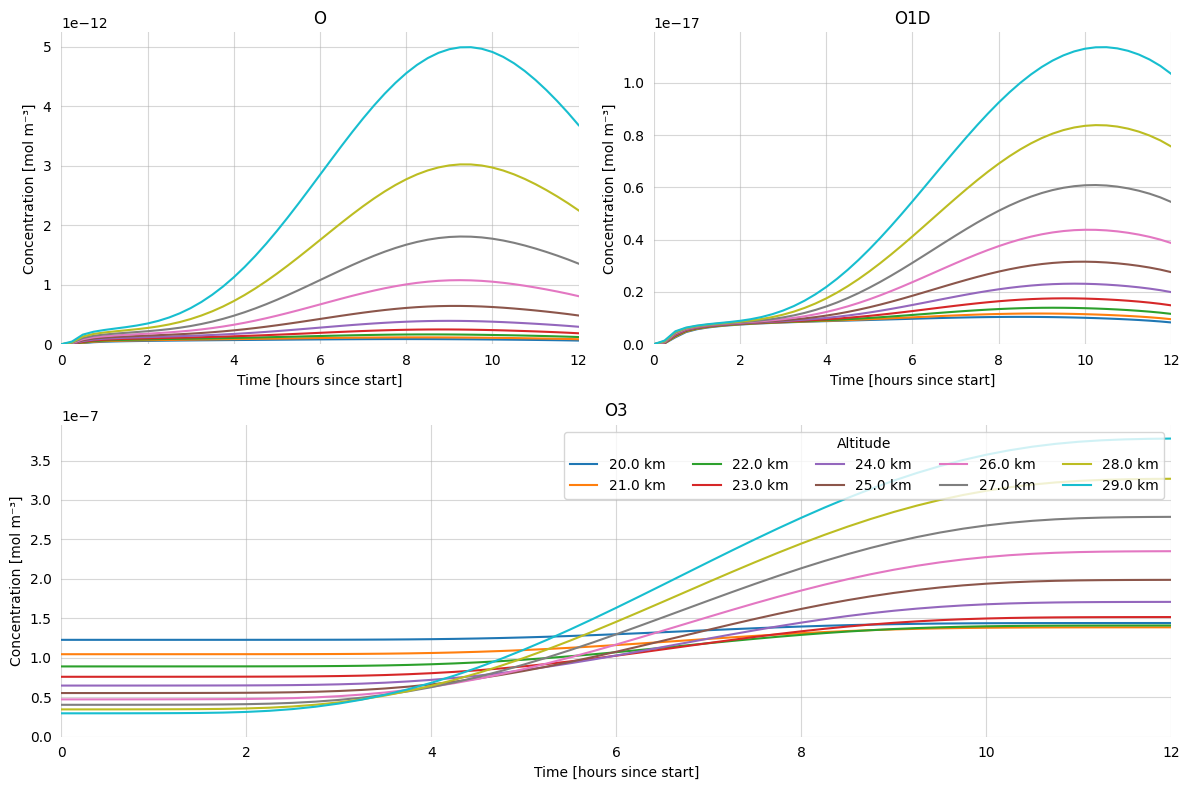

In [10]:
elapsed_hours = (ds['time'] - ds['time'].isel(time=0)) / np.timedelta64(1, 'h')

fig = plt.figure(figsize=(12, 8))
gs  = fig.add_gridspec(2, 2)

ax_o   = fig.add_subplot(gs[0, 0])
ax_o1d = fig.add_subplot(gs[0, 1])
ax_o3  = fig.add_subplot(gs[1, :])

for cell in range(num_grid_cells):
    label = f"{vertical_edges[cell]:.1f} km"
    ax_o.plot(elapsed_hours,   ds['O'].isel(height=cell),   label=label)
    ax_o1d.plot(elapsed_hours, ds['O1D'].isel(height=cell), label=label)
    ax_o3.plot(elapsed_hours,  ds['O3'].isel(height=cell),  label=label)

for ax, title in [(ax_o, 'O'), (ax_o1d, 'O1D'), (ax_o3, 'O3')]:
    ax.set_title(title)
    ax.set_xlabel('Time [hours since start]')
    ax.set_ylabel('Concentration [mol m⁻³]')
    ax.set_xlim(0, simulation_length / SECONDS_PER_HOUR)
    ax.set_ylim(0, None)
    ax.grid(True, alpha=0.5)
    ax.spines[:].set_visible(False)
    ax.tick_params(width=0)

handles, labels = ax_o3.get_legend_handles_labels()
ax_o3.legend(handles, labels, title='Altitude', ncol=5, loc='upper right')

fig.tight_layout()
plt.show()